# Task 1

Изображение загружено. Размер: (400, 600)
Тип данных: uint8
Мин/Макс: 0 / 255


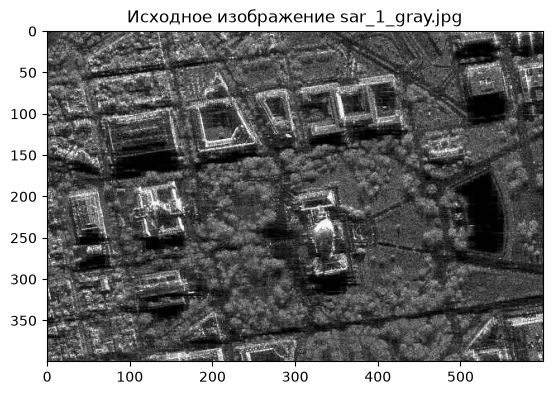

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

image_gray = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)

print(f"Изображение загружено. Размер: {image_gray.shape}")
print(f"Тип данных: {image_gray.dtype}")
print(f"Мин/Макс: {image_gray.min()} / {image_gray.max()}")

plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение sar_1_gray.jpg')
plt.show()

# Task 2

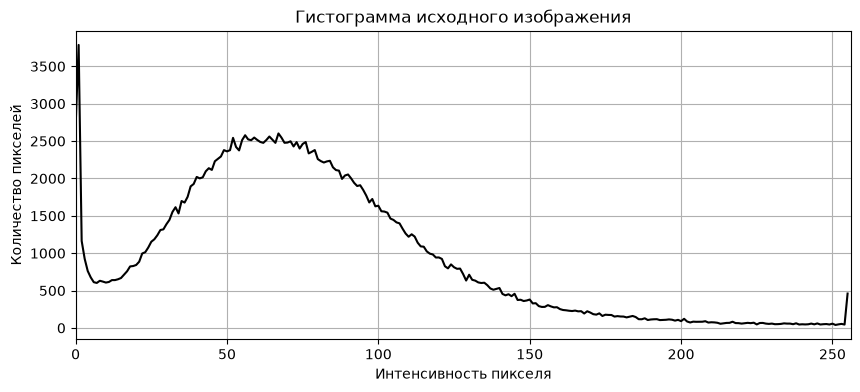

Общее количество пикселей: 240000
Сумма гистограммы: 240000
Минимум: 0, Максимум: 255


In [2]:
hist = cv2.calcHist([image_gray], [0], None, [256], (0, 256), accumulate=False)

plt.figure(figsize=(10, 4))
plt.plot(hist, color='black')
plt.title('Гистограмма исходного изображения')
plt.xlabel('Интенсивность пикселя')
plt.ylabel('Количество пикселей')
plt.xlim([0, 256])
plt.grid(True)
plt.show()

print(f"Общее количество пикселей: {image_gray.size}")
print(f"Сумма гистограммы: {int(hist.sum())}")
print(f"Минимум: {image_gray.min()}, Максимум: {image_gray.max()}")

# Task 3

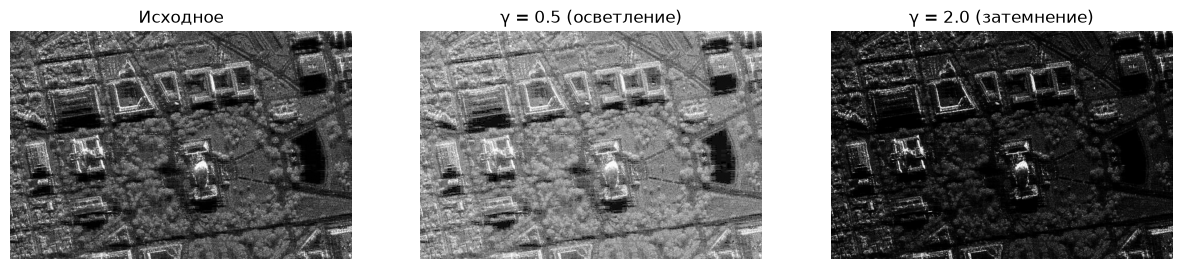

In [3]:
def gamma_correction(img, gamma):
    img_normalized = img / 255.0
    img_corrected = np.power(img_normalized, gamma)
    return (img_corrected * 255).astype(np.uint8)

gamma_bright = 0.5
gamma_dark = 2.0

image_gamma_bright = gamma_correction(image_gray, gamma_bright)
image_gamma_dark = gamma_correction(image_gray, gamma_dark)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(image_gray, cmap='gray'); plt.title('Исходное'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(image_gamma_bright, cmap='gray'); plt.title(f'γ = {gamma_bright} (осветление)'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(image_gamma_dark, cmap='gray'); plt.title(f'γ = {gamma_dark} (затемнение)'); plt.axis('off')
plt.show()

# Task 4

In [4]:
mse_bright = mean_squared_error(image_gray, image_gamma_bright)
ssim_bright = structural_similarity(image_gray, image_gamma_bright)
mse_dark = mean_squared_error(image_gray, image_gamma_dark)
ssim_dark = structural_similarity(image_gray, image_gamma_dark)

print(f"Сравнение исходного и осветленного (γ={gamma_bright}):")
print(f"  MSE:  {mse_bright:.4f}")
print(f"  SSIM: {ssim_bright:.4f}")
print(f"\nСравнение исходного и затемненного (γ={gamma_dark}):")
print(f"  MSE:  {mse_dark:.4f}")
print(f"  SSIM: {ssim_dark:.4f}")

Сравнение исходного и осветленного (γ=0.5):
  MSE:  3250.4291
  SSIM: 0.7875

Сравнение исходного и затемненного (γ=2.0):
  MSE:  2383.7636
  SSIM: 0.5270


# Task 5

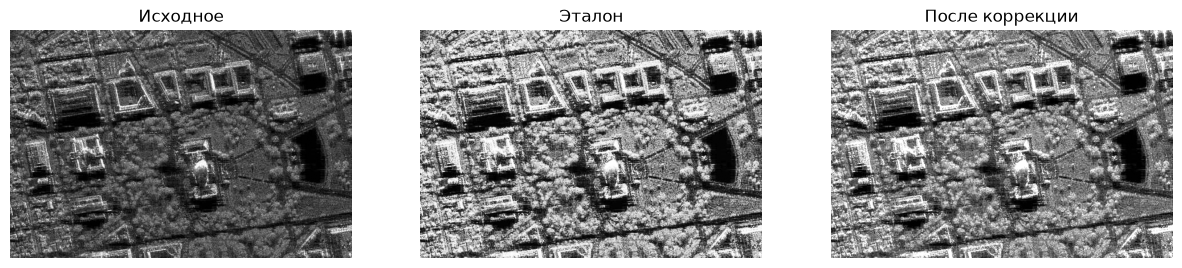

Исходное: mean=74.94, std=43.66
Эталон: mean=127.03, std=74.27
После Коррекции: mean=123.12, std=65.30


In [5]:
def statistical_color_correction(source_img, target_img):
    mean_s = np.mean(source_img)
    std_s  = np.std(source_img)
    mean_t = np.mean(target_img)
    std_t  = np.std(target_img)
    corrected = mean_s + (target_img.astype(np.float64) - mean_t) * (std_s / std_t)
    return np.clip(corrected, 0, 255).astype(np.uint8)

eq_gray = cv2.equalizeHist(image_gray)
source_image_for_correction = image_gray
image_stat_corrected = statistical_color_correction(eq_gray, source_image_for_correction)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(source_image_for_correction, cmap='gray'); plt.title('Исходное'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(eq_gray, cmap='gray'); plt.title('Эталон'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(image_stat_corrected, cmap='gray'); plt.title('После коррекции'); plt.axis('off')
plt.show()

print(f"Исходное: mean={np.mean(source_image_for_correction):.2f}, std={np.std(source_image_for_correction):.2f}")
print(f"Эталон: mean={np.mean(eq_gray):.2f}, std={np.std(eq_gray):.2f}")
print(f"После Коррекции: mean={np.mean(image_stat_corrected):.2f}, std={np.std(image_stat_corrected):.2f}")

# Task 6

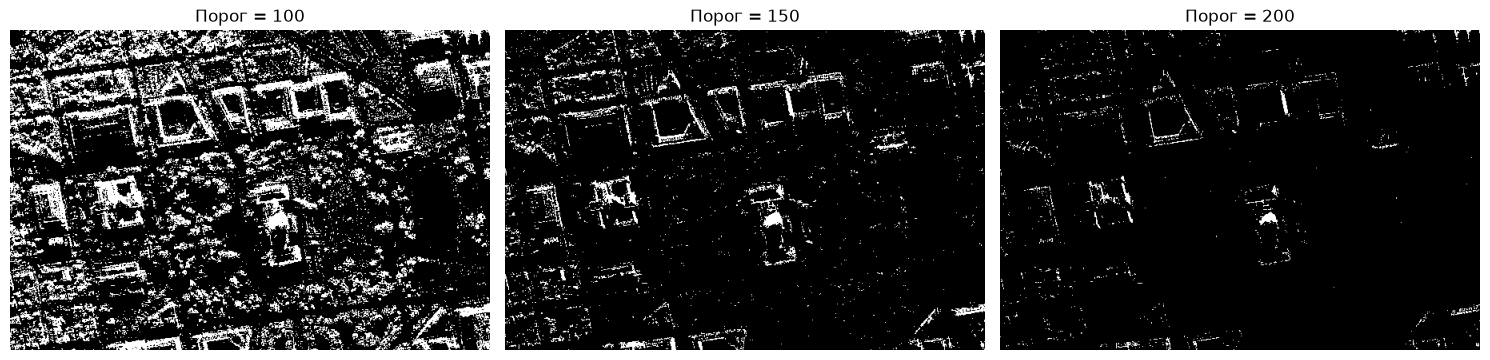

In [6]:
_, thresh1 = cv2.threshold(image_gray, 100, 255, cv2.THRESH_BINARY)
_, thresh2 = cv2.threshold(image_gray, 150, 255, cv2.THRESH_BINARY)
_, thresh3 = cv2.threshold(image_gray, 200, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(thresh1, cmap='gray'); plt.title('Порог = 100'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(thresh2, cmap='gray'); plt.title('Порог = 150'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(thresh3, cmap='gray'); plt.title('Порог = 200'); plt.axis('off')
plt.tight_layout()
plt.show()